In [1]:
#libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
#load the parsed dataset
data_path = os.path.expanduser("~/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/data/processed/Universal-Diff-SI-Link/via_link_dataset.pt")
dataset = torch.load(data_path)

# verify the parameters (should be 14 parameters as per the dataset description)
print("Generated dataset features:")
print(f"Number of extracted features: {len(dataset['feature_names'])}")
print(f"Names of extracted features: {dataset['feature_names']}\n")


Generated dataset features:
Number of extracted features: 16
Names of extracted features: ['PERMITTIVITY', 'CONDUCTIVITY', 'LOSTANGENT', 'TDIEL', 'TMET', 'LAYER_AMOUNT', 'VIAS_X_AMOUNT', 'VIAS_Y_AMOUNT', 'VIA_RADIUS', 'LENGTH', 'SL_WIDTH', 'ANTIPAD_RADIUS', 'PITCH', 'SIGNAL_AMOUNT', 'GROUND_AMOUNT', 'POWER_AMOUNT']



In [ ]:
#verify the frequency range (should be 0.25 GHz to 100 GHz as per the dataset description)
print("Frequency range of the dataset:")
frequency_hz = dataset['frequencies'].numpy()
frequency_ghz = frequency_hz / 1e9 #convert to GHz
print(f"Total frequency points: {len(frequency_ghz)}")
print(f"Sweep range: {frequency_ghz.min():.2f} GHz to {frequency_ghz.max():.2f} GHz\n")

Frequency range of the dataset:
Total frequency points: 400
Sweep range: 0.25 GHz to 100.00 GHz



plotting the simulated S-parameters for the first sample in the dataset...


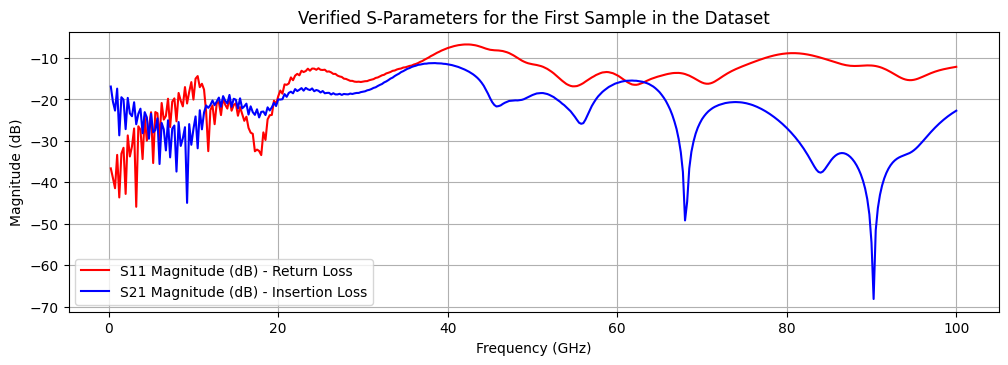

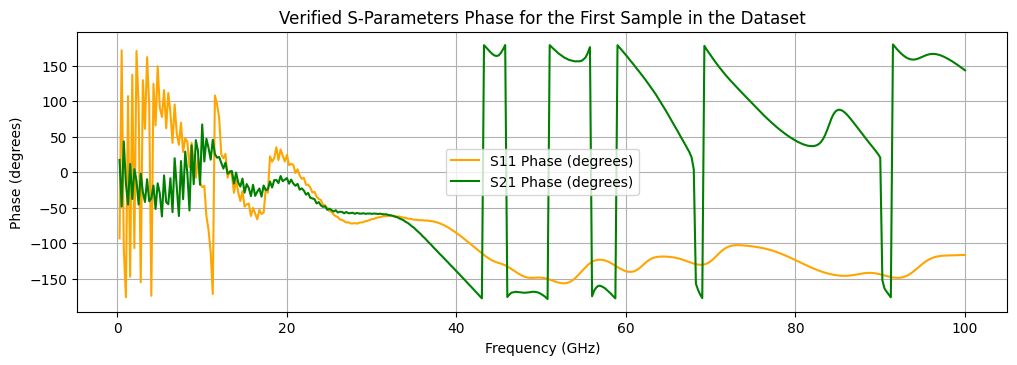

In [6]:
#verify the extracted S-parameters 
print("plotting the simulated S-parameters for the first sample in the dataset...")
Y_real = dataset['Y_real'][0].numpy()   # S11 real part for the first sample
Y_imag = dataset['Y_imag'][0].numpy()   # S11 imaginary part for the first sample

#calculate magnitude and phase for s11 (index 0,0) and s21 (index 1,0)
#adding a small epsilon to avoid log of zero
epsilon = 1e-12
s11_magnitude_db = 20 * np.log10(np.sqrt(Y_real[:,0,0]**2 + Y_imag[:,0,0]**2) + epsilon)
s11_phase_deg = np.arctan2(Y_imag[:,0,0], Y_real[:,0,0]) * (180 / np.pi)
s21_magnitude_db = 20 * np.log10(np.sqrt(Y_real[:,1,0]**2 + Y_imag[:,1,0]**2) + epsilon)
s21_phase_deg = np.arctan2(Y_imag[:,1,0], Y_real[:,1,0]) * (180 / np.pi)

#plot the magnitude and phase of s11 and s21
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(frequency_ghz, s11_magnitude_db, label='S11 Magnitude (dB) - Return Loss', color='red')
plt.plot(frequency_ghz, s21_magnitude_db, label='S21 Magnitude (dB) - Insertion Loss', color='blue')
plt.title('Verified S-Parameters for the First Sample in the Dataset')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 2)
plt.plot(frequency_ghz, s11_phase_deg, label='S11 Phase (degrees)', color='orange')
plt.plot(frequency_ghz, s21_phase_deg, label='S21 Phase (degrees)', color='green')
plt.title('Verified S-Parameters Phase for the First Sample in the Dataset')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Phase (degrees)')
plt.grid()
plt.legend()
plt.show()


In [ ]:
csv_path=os.path.expanduser("~/mece_project_inverse_model/Generative_Inverse_Design_of_High-Speed_Interconnects/data/raw/Universal-Diff-SI-Link/parameter.csv")
df=pd.read_csv(csv_path)
#sample data used - 1st sample
sample_data=df.iloc[0]
print("\n"+"-"*50)
print("Physical parameters for first sample")
print("\n"+"-"*50)
for feature, value in sample_data.items():
    print(f"{feature}: {value}")
print("-"*50)